<a href="https://colab.research.google.com/github/ClassNeuralNetwork/Credit-Card-Fraud-Detection/blob/main/Projeto_I_Teste_software.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importando as bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.gridspec as gridspec
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.metrics import confusion_matrix,precision_recall_curve,auc,roc_auc_score,roc_curve,recall_score,classification_report

# Configuração global de estilo
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({'font.size': 12, 'figure.facecolor': 'white'})

#Importação do dataset

* fonte: https://www.kaggle.com/datasets/nudratabbas/global-supply-chain-risk-and-logistics-2024-2026

In [ ]:
import kagglehub

path = kagglehub.dataset_download("nudratabbas/global-supply-chain-risk-and-logistics-2024-2026")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'global-supply-chain-risk-and-logistics-2024-2026' dataset.
Path to dataset files: /kaggle/input/global-supply-chain-risk-and-logistics-2024-2026


In [ ]:

df = pd.read_csv('/kaggle/input/global-supply-chain-risk-and-logistics-2024-2026/global_supply_chain_risk_2026.csv')
df

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,SC-14995,2025-11-10,Rotterdam,Dubai,Rail,Perishables,13512.26,428.97,3.35,8.8,Fog,0.664,20.28,0
4996,SC-14996,2025-11-23,Dubai,Shanghai,Air,Perishables,2231.02,448.86,1.79,0.5,Clear,0.863,0.50,0
4997,SC-14997,2025-10-18,Antwerp,Busan,Rail,Pharmaceuticals,5253.72,473.41,1.37,3.0,Clear,0.962,4.41,0
4998,SC-14998,2025-01-29,Singapore,Dubai,Rail,Automotive,12328.31,199.35,3.45,4.4,Storm,0.819,31.18,1


In [ ]:
hasNan = df.isna().sum()
print(hasNan)

Shipment_ID                  0
Date                         0
Origin_Port                  0
Destination_Port             0
Transport_Mode               0
Product_Category             0
Distance_km                  0
Weight_MT                    0
Fuel_Price_Index             0
Geopolitical_Risk_Score      0
Weather_Condition            0
Carrier_Reliability_Score    0
Lead_Time_Days               0
Disruption_Occurred          0
dtype: int64


<Axes: >

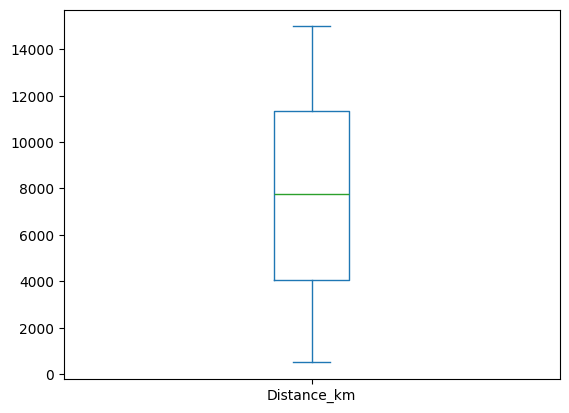

In [ ]:
df['Distance_km'].plot(kind = 'box')

<Axes: >

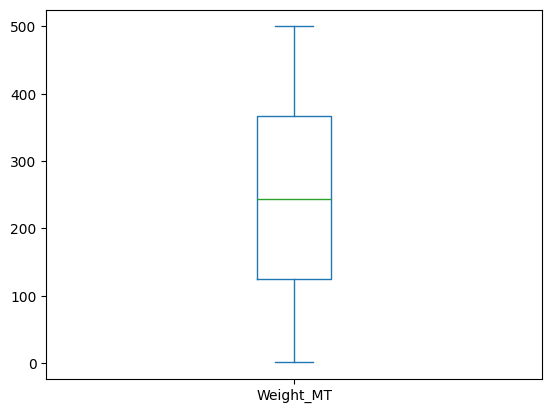

In [ ]:
df['Weight_MT'].plot(kind = 'box')

<Axes: >

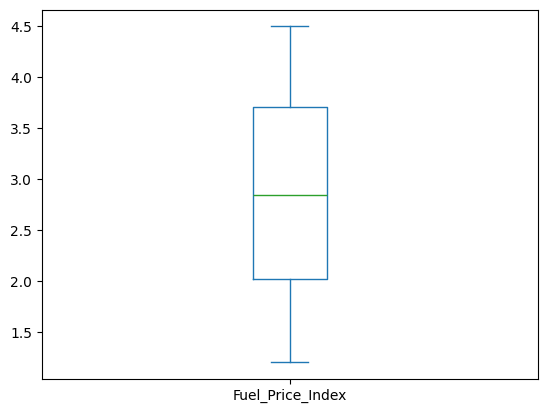

In [ ]:
df['Fuel_Price_Index'].plot(kind = 'box')

<Axes: >

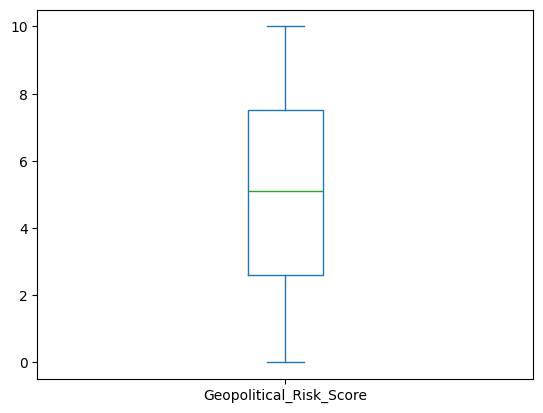

In [ ]:
df['Geopolitical_Risk_Score'].plot(kind = 'box')

<Axes: >

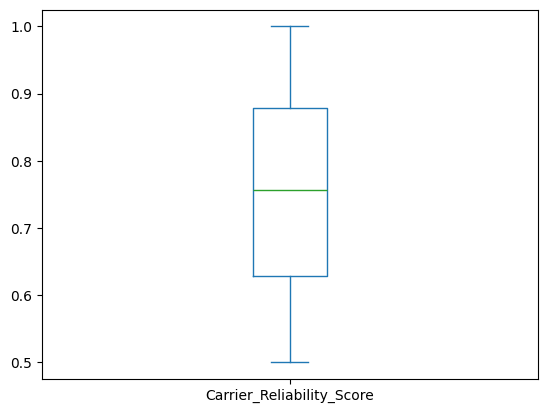

In [ ]:
df['Carrier_Reliability_Score'].plot(kind = 'box')

<Axes: >

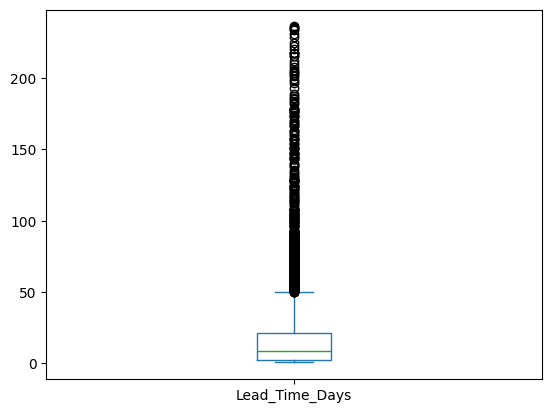

In [ ]:
df['Lead_Time_Days'].plot(kind = 'box')

#Tratamento de Dados: Eliminando os Outliers

Algumas colunas do dataset, como Lead_Time_Days, podem apresentar valores discrepantes que prejudicam a análise e apredição do modelo, devido à má distribuição dos dados. para tratar esse problema, os outliers serão identificados por meio de boxplots aplicados aos atributos selecionados. Em seguida, será utilizada a regra de 1,5*IQR (Intervalo Interquartil) para removê-los.

In [ ]:
#trata outlier pela regra do 1.5*IQR (variação interquartil)


q1 = df['Lead_Time_Days'].quantile(0.25) #primeiro quartil
q3 = df['Lead_Time_Days'].quantile(0.75)  #terceiro quartil
iqr = q3 - q1
lLim = 0
hLim = q3 + 1.5 * iqr
print(lLim)
print(hLim)

0
49.853750000000005


In [ ]:
df.loc[df['Lead_Time_Days'] < lLim, 'Lead_Time_Days']=lLim

In [ ]:
df.loc[df['Lead_Time_Days'] > hLim, 'Lead_Time_Days'] =hLim

#Tratamento de Dados

Converte variáveis categóricas (texto) em valores numéricos para que possam ser utilizadas pela rede neural.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Origin_Port'] = le.fit_transform(df['Origin_Port'])
df['Destination_Port'] = le.fit_transform(df['Destination_Port'])
df['Transport_Mode'] = le.fit_transform(df['Transport_Mode'])
df['Product_Category'] = le.fit_transform(df['Product_Category'])
df['Weather_Condition'] = le.fit_transform(df['Product_Category'])

In [ ]:
df

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,7,4,1,4,5930.83,197.42,2.43,5.0,4,0.865,41.39000,1
1,SC-10001,2024-04-24,7,7,1,0,14285.36,237.24,2.30,7.5,0,0.592,40.92000,1
2,SC-10002,2024-01-26,5,4,1,2,11113.91,427.42,1.78,5.6,2,0.673,11.54000,0
3,SC-10003,2024-10-08,1,3,1,1,9180.55,170.66,3.20,0.8,1,0.832,49.85375,1
4,SC-10004,2024-09-07,1,8,0,2,2762.27,434.96,2.77,1.9,2,0.741,0.50000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,SC-14995,2025-11-10,5,2,1,2,13512.26,428.97,3.35,8.8,2,0.664,20.28000,0
4996,SC-14996,2025-11-23,2,7,0,2,2231.02,448.86,1.79,0.5,2,0.863,0.50000,0
4997,SC-14997,2025-10-18,0,1,1,3,5253.72,473.41,1.37,3.0,3,0.962,4.41000,0
4998,SC-14998,2025-01-29,7,2,1,0,12328.31,199.35,3.45,4.4,0,0.819,31.18000,1


#Normalização dos Dados

os dados são normalizados para o intervalo [0,1], garantindo que todas as variáveis tenham a mesma escala.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

df[['Distance_km', 'Weight_MT', 'Lead_Time_Days']] = MinMaxScaler().fit_transform(df[['Distance_km', 'Weight_MT', 'Lead_Time_Days']])

df

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,7,4,1,4,0.374638,0.393788,2.43,5.0,4,0.865,0.828508,1
1,SC-10001,2024-04-24,7,7,1,0,0.950982,0.473632,2.30,7.5,0,0.592,0.818985,1
2,SC-10002,2024-01-26,5,4,1,2,0.732197,0.854969,1.78,5.6,2,0.673,0.223691,0
3,SC-10003,2024-10-08,1,3,1,1,0.598823,0.340131,3.20,0.8,1,0.832,1.000000,1
4,SC-10004,2024-09-07,1,8,0,2,0.156053,0.870087,2.77,1.9,2,0.741,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,SC-14995,2025-11-10,5,2,1,2,0.897649,0.858077,3.35,8.8,2,0.664,0.400780,0
4996,SC-14996,2025-11-23,2,7,0,2,0.119404,0.897959,1.79,0.5,2,0.863,0.000000,0
4997,SC-14997,2025-10-18,0,1,1,3,0.327927,0.947185,1.37,3.0,3,0.962,0.079224,0
4998,SC-14998,2025-01-29,7,2,1,0,0.815974,0.397658,3.45,4.4,0,0.819,0.621635,1


#Remoção de Colunas Irrelevantes

Remove as colunas que não contribuem para o modelo.

In [ ]:
drop = ['Shipment_ID', 'Date']
df.drop(columns=drop,inplace=True)
df

,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,7,4,1,4,0.374638,0.393788,2.43,5.0,4,0.865,0.828508,1
1,7,7,1,0,0.950982,0.473632,2.30,7.5,0,0.592,0.818985,1
2,5,4,1,2,0.732197,0.854969,1.78,5.6,2,0.673,0.223691,0
3,1,3,1,1,0.598823,0.340131,3.20,0.8,1,0.832,1.000000,1
4,1,8,0,2,0.156053,0.870087,2.77,1.9,2,0.741,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5,2,1,2,0.897649,0.858077,3.35,8.8,2,0.664,0.400780,0
4996,2,7,0,2,0.119404,0.897959,1.79,0.5,2,0.863,0.000000,0
4997,0,1,1,3,0.327927,0.947185,1.37,3.0,3,0.962,0.079224,0
4998,7,2,1,0,0.815974,0.397658,3.45,4.4,0,0.819,0.621635,1


In [ ]:
df.columns.values

array(['Origin_Port', 'Destination_Port', 'Transport_Mode',
       'Product_Category', 'Distance_km', 'Weight_MT', 'Fuel_Price_Index',
       'Geopolitical_Risk_Score', 'Weather_Condition',
       'Carrier_Reliability_Score', 'Lead_Time_Days',
       'Disruption_Occurred'], dtype=object)

In [ ]:
atributos = ['Origin_Port', 'Destination_Port', 'Transport_Mode',
       'Product_Category', 'Distance_km', 'Weight_MT', 'Fuel_Price_Index',
       'Geopolitical_Risk_Score', 'Weather_Condition',
       'Carrier_Reliability_Score', 'Lead_Time_Days',
       'Disruption_Occurred']

<Axes: >

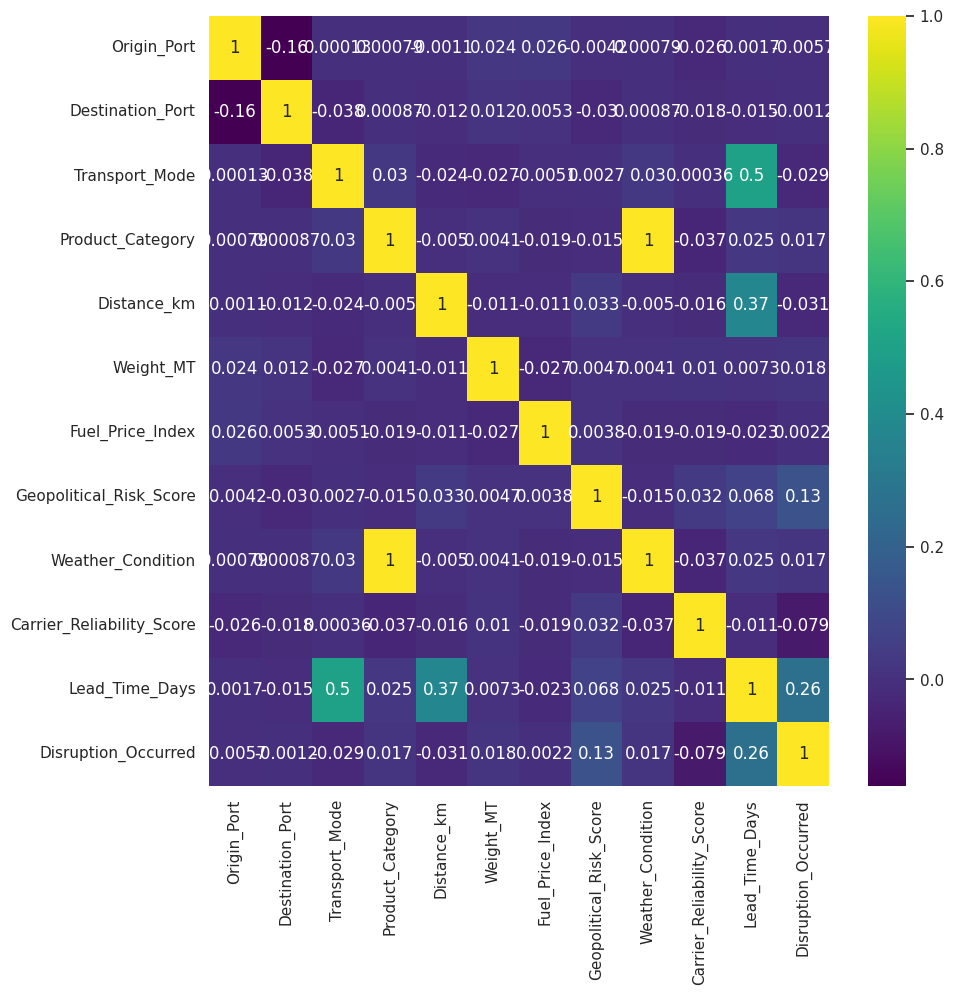

In [ ]:
corr = df[atributos].corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='viridis')

In [ ]:
df['Disruption_Occurred'].value_counts()

,count
Disruption_Occurred,
1,3063
0,1937


In [ ]:
from imblearn.under_sampling import NearMiss

X, y = NearMiss().fit_resample(df.drop(columns=['Disruption_Occurred']), df['Disruption_Occurred'])

df = pd.DataFrame(X, columns=df.columns.drop('Disruption_Occurred'))
df['Disruption_Occurred'] = y
df

,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,5,4,1,2,0.732197,0.854969,1.78,5.6,2,0.673,0.223691,0
1,6,0,1,3,0.058089,0.777170,1.31,2.6,3,0.981,0.050452,0
2,2,6,1,2,0.020579,0.165524,4.12,0.7,2,0.707,0.000000,0
3,4,1,2,2,0.304320,0.041466,1.22,5.1,2,0.871,0.066054,0
4,1,6,0,0,0.432060,0.559994,1.53,1.9,0,0.800,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3869,5,0,2,2,0.519526,0.432628,2.57,5.5,2,0.930,0.346276,1
3870,5,7,2,1,0.507197,0.548645,3.33,9.3,1,0.643,0.204037,1
3871,6,2,2,1,0.737079,0.078501,1.49,9.0,1,0.826,0.177697,1
3872,6,8,2,4,0.806890,0.209336,2.34,0.5,4,0.615,1.000000,1


In [ ]:
entrada = df.drop('Disruption_Occurred', axis=1)
saida_desejada = df['Disruption_Occurred'].values

entrada_train, entrada_test, saida_desejada_train, saida_desejada_test = train_test_split(entrada, saida_desejada, test_size=0.2, random_state=42)

#Divisão Treino/Teste

* 80% treino
* 20% teste

#Padronização dos Dados

In [ ]:
scaler = StandardScaler()
entrada_train_padronizados = scaler.fit_transform(entrada_train)
entrada_test_padronizados = scaler.transform(entrada_test)


#Criando a Rede Neural

In [ ]:
modelo = tf.keras.models.Sequential()
modelo.add(tf.keras.layers.Input(shape=(entrada_train.shape[1],)))
modelo.add(tf.keras.layers.Dense(units=128, activation='relu'))
modelo.add(tf.keras.layers.Dropout(0.3)) # Adicionando 30% de dropout
modelo.add(tf.keras.layers.Dense(units=64, activation='relu'))
modelo.add(tf.keras.layers.Dropout(0.2)) # Adicionando 20% de dropout
modelo.add(tf.keras.layers.Dense(units=1, activation='sigmoid')) # Sigmoid para classificação binária
modelo.summary()

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_87 (Dense)                │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,857 (38.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
historico = modelo.fit(entrada_train_padronizados, saida_desejada_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.5668 - loss: 0.6702 - val_accuracy: 0.6532 - val_loss: 0.6076
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6240 - loss: 0.6228 - val_accuracy: 0.6774 - val_loss: 0.5851
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6438 - loss: 0.6094 - val_accuracy: 0.6726 - val_loss: 0.5790
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6527 - loss: 0.6021 - val_accuracy: 0.6823 - val_loss: 0.5790
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6624 - loss: 0.5974 - val_accuracy: 0.6629 - val_loss: 0.5803
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6700 - loss: 0.5863 - val_accuracy: 0.6823 - val_loss: 0.5838
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6688 - loss: 0.5892 - val_accuracy: 0.6726 - val_loss: 0.5801
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6676 - loss: 0.5892 - val_accuracy: 0

In [ ]:
saida_desejada_pred = modelo.predict(entrada_test)
saida_desejada_pred = saida_desejada_pred.reshape(saida_desejada_pred.shape[0]
                                                  )
print('MSE: ', mean_squared_error(saida_desejada_test, saida_desejada_pred))
print('R2: ', r2_score(saida_desejada_test, saida_desejada_pred))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE:  0.315408855676651
R2:  -0.2619905471801758


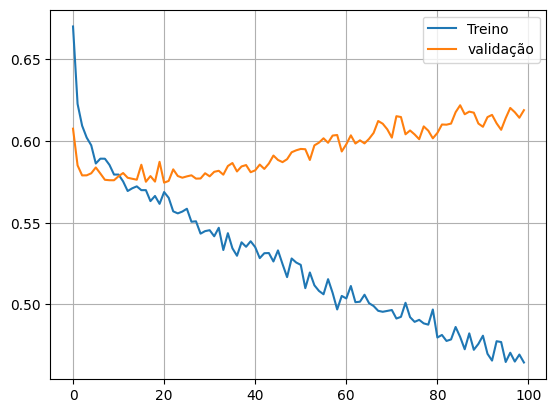

In [ ]:
plt.plot(historico.history['loss'], label='Treino')
plt.plot(historico.history['val_loss'], label='validação')
plt.legend()
#plt.yscale('log')
plt.grid(True)
plt.show()

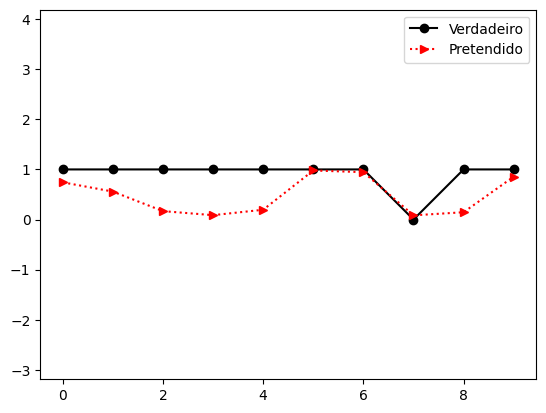

In [ ]:
plt.plot(saida_desejada_test[0:10], '-o', color='black')
plt.plot(saida_desejada_pred[0:10], ':>', color='red')
plt.axis('equal')
plt.legend(['Verdadeiro', 'Pretendido'])

In [ ]:
# Avaliando a predição do modelo - teste
saida_predita = modelo.predict(entrada_train) #vetor de saídas preditas



97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
entrada = df.drop('Disruption_Occurred', axis=1)
saida = df['Disruption_Occurred'].values

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Nova Acurácia com Dropout: 64.65%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.64      0.71      0.67       394
           1       0.66      0.58      0.62       381

    accuracy                           0.65       775
   macro avg       0.65      0.65      0.64       775
weighted avg       0.65      0.65      0.64       775



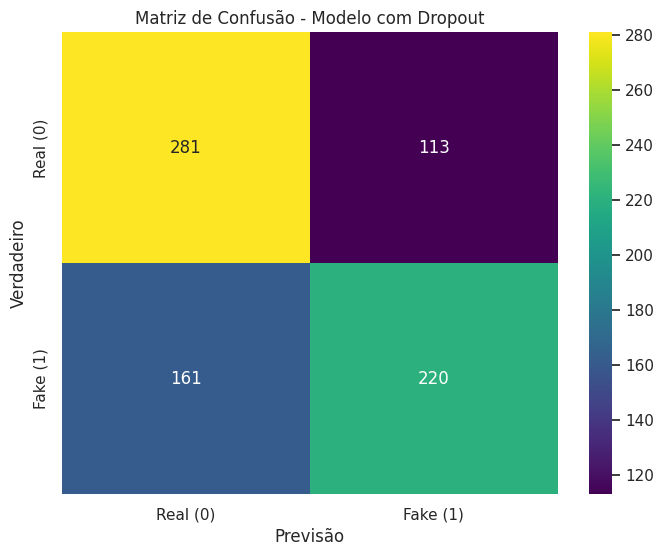

In [ ]:

previsoes_probabilidade = modelo.predict(entrada_test_padronizados)
previsoes_finais = (previsoes_probabilidade > 0.5).astype(int)


acuracia = accuracy_score(saida_desejada_test, previsoes_finais)
matriz_confusao = confusion_matrix(saida_desejada_test, previsoes_finais)

print(f"Nova Acurácia com Dropout: {acuracia * 100:.2f}%\n")
print("Relatório de Classificação:")
print(classification_report(saida_desejada_test, previsoes_finais))


plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='viridis',
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'])
plt.title('Matriz de Confusão - Modelo com Dropout')
plt.xlabel('Previsão')
plt.ylabel('Verdadeiro')
plt.show()

### Otimização de Hiperparâmetros com GridSearch

Nesta etapa, utilizaremos o `GridSearchCV` para testar diferentes combinações de parâmetros e encontrar a configuração que maximiza a acurácia do modelo.

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

params = [
    {'neuronios': 64, 'learning_rate': 0.001, 'batch_size': 32},
    {'neuronios': 128, 'learning_rate': 0.01, 'batch_size': 64}
]

best_score = 0
best_params = None

for p in params:
    kf = KFold(n_splits=3)
    scores = []
    for train_idx, val_idx in kf.split(entrada_train_padronizados):
        X_t, X_v = entrada_train_padronizados[train_idx], entrada_train_padronizados[val_idx]
        y_t, y_v = saida_desejada_train[train_idx], saida_desejada_train[val_idx]

        model = tf.keras.models.Sequential([
            tf.keras.layers.Input(shape=(X_t.shape[1],)),
            tf.keras.layers.Dense(units=p['neuronios'], activation='relu'),
            tf.keras.layers.Dense(units=p['neuronios'] // 2, activation='relu'),
            tf.keras.layers.Dense(units=1, activation='sigmoid')
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=p['learning_rate']),
                      loss='binary_crossentropy', metrics=['accuracy'])

        model.fit(X_t, y_t, epochs=30, batch_size=p['batch_size'], verbose=0)
        y_pred = (model.predict(X_v) > 0.5).astype(int)
        scores.append(accuracy_score(y_v, y_pred))

    avg_score = np.mean(scores)
    if avg_score > best_score:
        best_score = avg_score
        best_params = p

print(f"Melhor acurácia média: {best_score} usando {best_params}")

grid_result_model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(entrada_train_padronizados.shape[1],)),
    tf.keras.layers.Dense(units=best_params['neuronios'], activation='relu'),
    tf.keras.layers.Dense(units=best_params['neuronios'] // 2, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='sigmoid')
])
grid_result_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
                          loss='binary_crossentropy', metrics=['accuracy'])
grid_result_model.fit(entrada_train_padronizados, saida_desejada_train, epochs=50, batch_size=best_params['batch_size'], verbose=0)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Melhor acurácia média: 0.6569861245563086 usando {'neuronios': 64, 'learning_rate': 0.001, 'batch_size': 32}


### Avaliação do Melhor Modelo

Agora, vamos utilizar os melhores parâmetros encontrados para avaliar o desempenho final nos dados de teste.

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Relatório de Classificação Otimizado:
              precision    recall  f1-score   support

           0       0.63      0.60      0.62       394
           1       0.61      0.64      0.62       381

    accuracy                           0.62       775
   macro avg       0.62      0.62      0.62       775
weighted avg       0.62      0.62      0.62       775



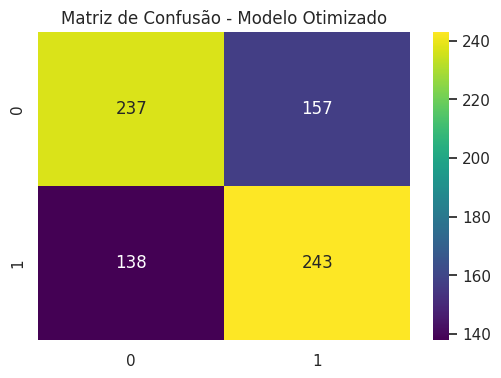

In [ ]:

previsoes_prob = grid_result_model.predict(entrada_test_padronizados)
previsoes_otimizadas = (previsoes_prob > 0.5).astype(int)

print("Relatório de Classificação Otimizado:")
print(classification_report(saida_desejada_test, previsoes_otimizadas))


plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(saida_desejada_test, previsoes_otimizadas), annot=True, fmt='d', cmap='viridis')
plt.title('Matriz de Confusão - Modelo Otimizado')
plt.show()

### Nova Abordagem: Engenharia de Recursos e Random Forest

Nesta etapa, vamos recuperar a coluna de data para extrair o 'mês' e o 'dia da semana', e testar um classificador Random Forest, que costuma ser muito robusto para este tipo de dado.

Relatório de Classificação - Random Forest:
              precision    recall  f1-score   support

           0       0.65      0.74      0.69       394
           1       0.68      0.58      0.63       381

    accuracy                           0.66       775
   macro avg       0.66      0.66      0.66       775
weighted avg       0.66      0.66      0.66       775



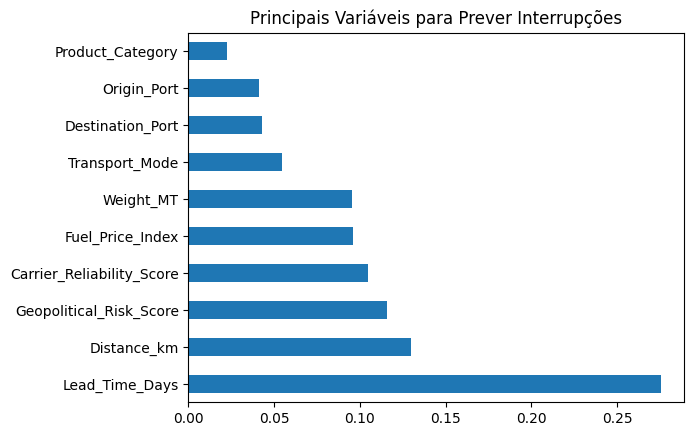

In [ ]:
from sklearn.ensemble import RandomForestClassifier



rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(entrada_train_padronizados, saida_desejada_train)

rf_pred = rf_model.predict(entrada_test_padronizados)

print("Relatório de Classificação - Random Forest:")
print(classification_report(saida_desejada_test, rf_pred))

importancias = pd.Series(rf_model.feature_importances_, index=entrada.columns)
importancias.nlargest(10).plot(kind='barh')
plt.title('Principais Variáveis para Prever Interrupções')
plt.show()

### Comparação de Desempenho: Dropout vs Otimizado

Nesta seção, consolidamos as métricas obtidas anteriormente para visualizar qual abordagem trouxe o melhor resultado nos dados de teste.

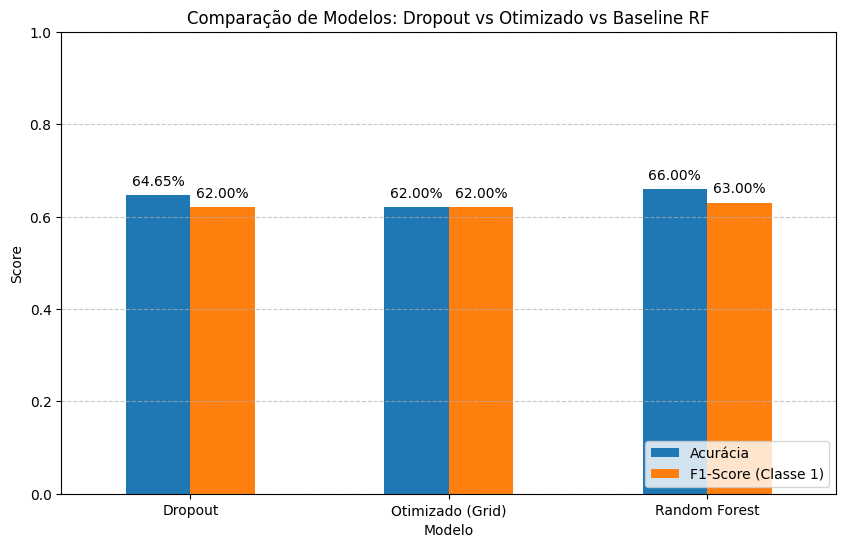

,Modelo,Acurácia,F1-Score (Classe 1)
0,Dropout,0.6465,0.62
1,Otimizado (Grid),0.6200,0.62
2,Random Forest,0.6600,0.63


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

resultados = {
    'Modelo': ['Dropout', 'Otimizado (Grid)', 'Random Forest'],
    'Acurácia': [0.6465, 0.6200, 0.6600],
    'F1-Score (Classe 1)': [0.62, 0.62, 0.63]
}

df_comp = pd.DataFrame(resultados)

fig, ax = plt.subplots(figsize=(10, 6))
df_comp.plot(x='Modelo', y=['Acurácia', 'F1-Score (Classe 1)'], kind='bar', ax=ax)

plt.title('Comparação de Modelos: Dropout vs Otimizado vs Baseline RF')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

display(df_comp)

### Importância das Variáveis (Random Forest)

Visualização dos atributos que mais influenciaram as decisões do modelo de Random Forest.

/tmp/ipykernel_12742/2056514056.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_importances, palette='viridis')


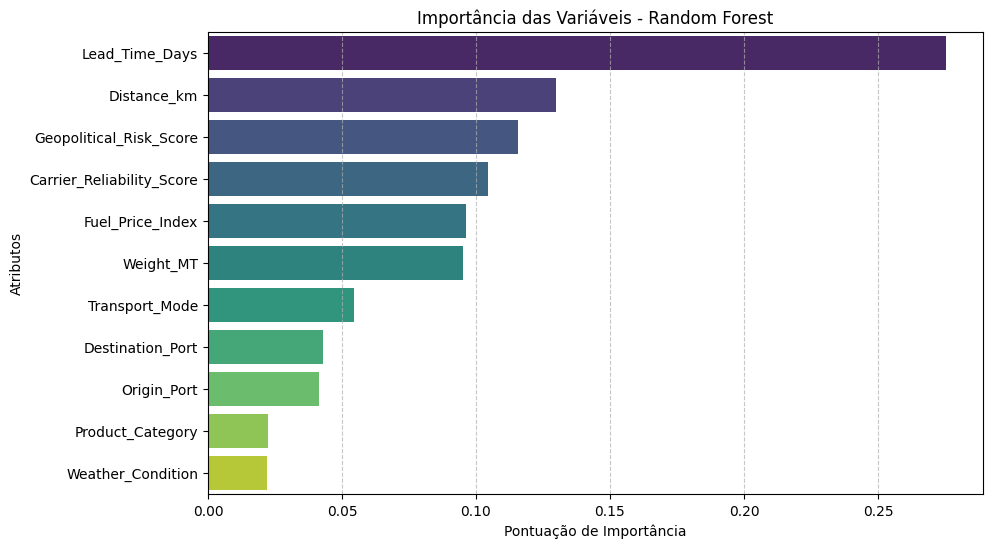

,Feature,Importance
10,Lead_Time_Days,0.275443
4,Distance_km,0.130005
7,Geopolitical_Risk_Score,0.115494
9,Carrier_Reliability_Score,0.104546
6,Fuel_Price_Index,0.096121
5,Weight_MT,0.095075
2,Transport_Mode,0.054438
1,Destination_Port,0.042968
0,Origin_Port,0.041400
3,Product_Category,0.022528


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


importancias = rf_model.feature_importances_
features = entrada.columns


feat_importances = pd.DataFrame({'Feature': features, 'Importance': importancias})
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_importances, palette='viridis')

plt.title('Importância das Variáveis - Random Forest')
plt.xlabel('Pontuação de Importância')
plt.ylabel('Atributos')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


display(feat_importances)

### Visualizações para Contextualização Científica

Nesta seção, geramos gráficos para descrever o comportamento estatístico da base de dados, úteis para a seção de 'Materiais e Métodos' ou 'Análise Exploratória' de um artigo.

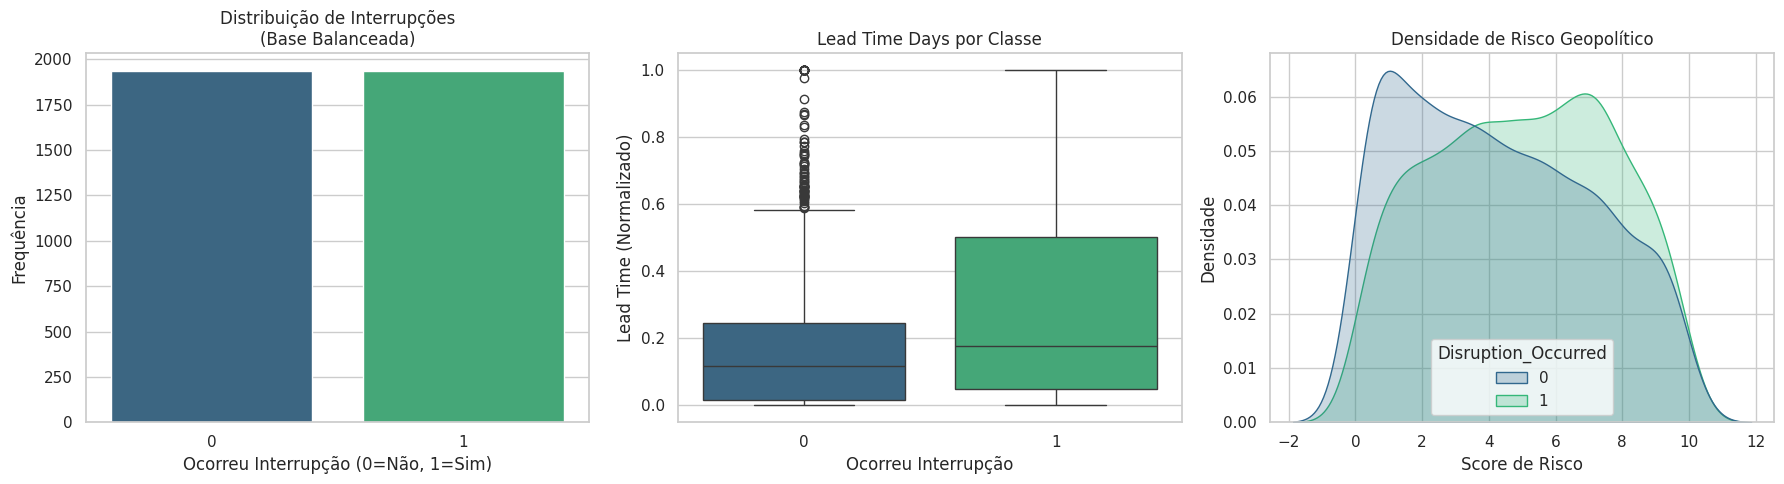

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)
sns.countplot(x='Disruption_Occurred', data=df, hue='Disruption_Occurred', palette='viridis', legend=False)
plt.title('Distribuição de Interrupções\n(Base Balanceada)')
plt.xlabel('Ocorreu Interrupção (0=Não, 1=Sim)')
plt.ylabel('Frequência')


plt.subplot(1, 3, 2)
sns.boxplot(x='Disruption_Occurred', y='Lead_Time_Days', data=df, hue='Disruption_Occurred', palette='viridis', legend=False)
plt.title('Lead Time Days por Classe')
plt.xlabel('Ocorreu Interrupção')
plt.ylabel('Lead Time (Normalizado)')


plt.subplot(1, 3, 3)
sns.kdeplot(data=df, x="Geopolitical_Risk_Score", hue="Disruption_Occurred", fill=True, palette='viridis')
plt.title('Densidade de Risco Geopolítico')
plt.xlabel('Score de Risco')
plt.ylabel('Densidade')

plt.tight_layout()
plt.show()

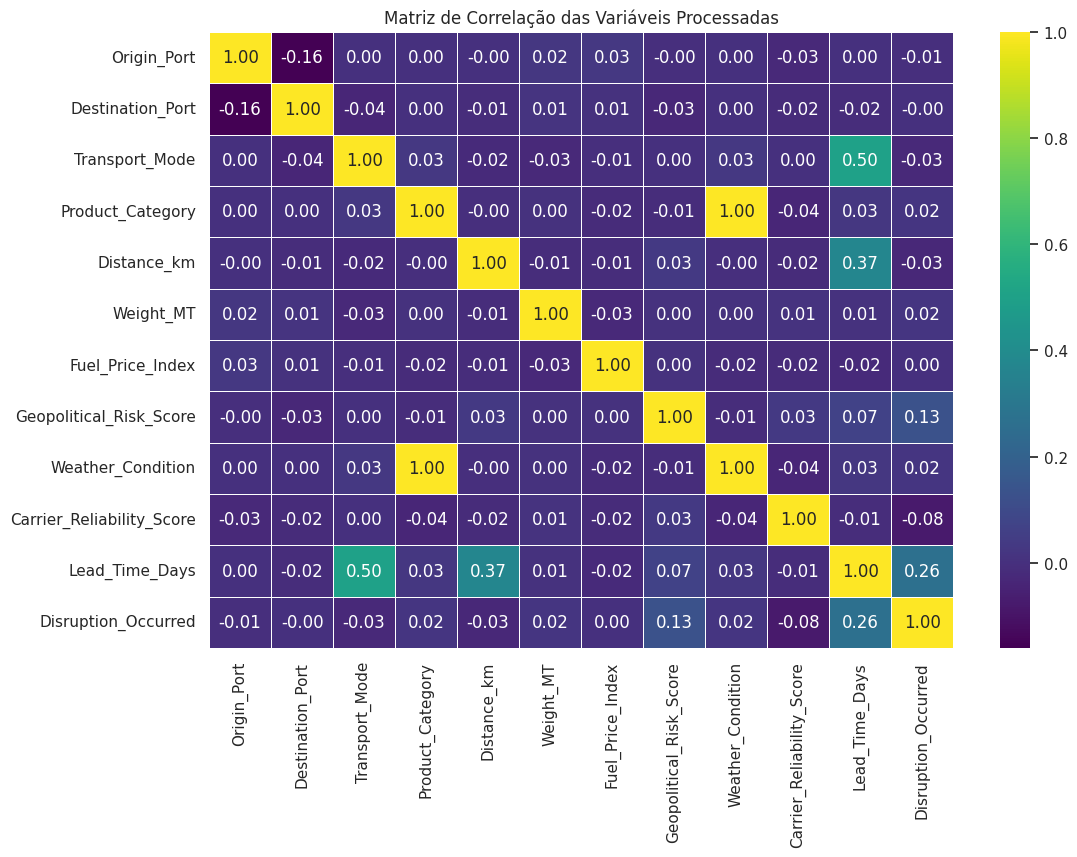

In [ ]:

plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis Processadas')
plt.show()